In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from collections import Counter
import os

In [3]:
path_to_folder = 'D:\\base'
path_to_file = path_to_folder + '\\disp_1.csv'

df = pd.read_csv(path_to_file, 
                 sep='\s+',           # разделитель: пробелы/табуляции
                 skiprows=1,          # пропускаем первую строку (заголовки не в том формате)
                 header=None,         # нет заголовков в данных
                 names=['el_id', 'el_a', 'el_b', 'Node1_UY', 'Node2_UX', 'Node3_UY'])  # задаем имена колонок

#print(df)
df['el_id'] = np.where((df['el_id'] >= 12613) & (df['el_id'] <= 12635), 25248 - df['el_id'], df['el_id'])
df['el_id'] = df['el_id'] - 12611

df = df.drop_duplicates()

df

,el_id,el_a,el_b,Node1_UY,Node2_UX,Node3_UY
0,1.0,0.75,1.45,-3.236724,-3.186431,-0.148842
1,2.0,0.54,1.17,-2.105566,-2.352659,-0.155641
2,49.0,1.21,0.83,-1.989172,-2.344222,8.947892
3,32.0,0.20,1.02,-1.493940,1.328918,2.753204
4,55.0,0.36,0.32,-0.018817,0.040055,0.350640
...,...,...,...,...,...,...
995,3.0,1.42,0.84,-10.139181,-4.449504,1.313130
996,16.0,1.21,0.90,-17.175308,-6.722642,7.790580
997,1.0,1.03,1.45,-5.885054,-3.886978,0.047695
998,35.0,1.34,1.37,-17.153036,2.245698,23.825373


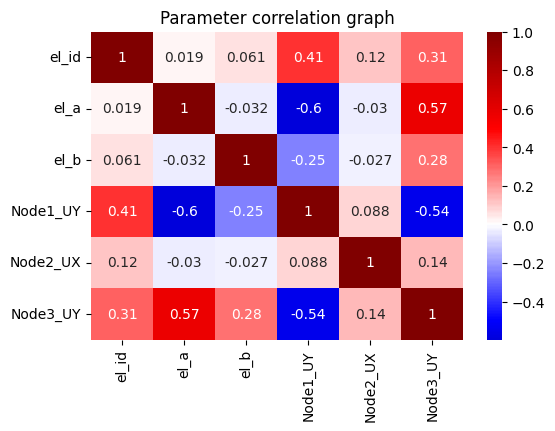

In [3]:
plt.figure(figsize=(6, 4))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

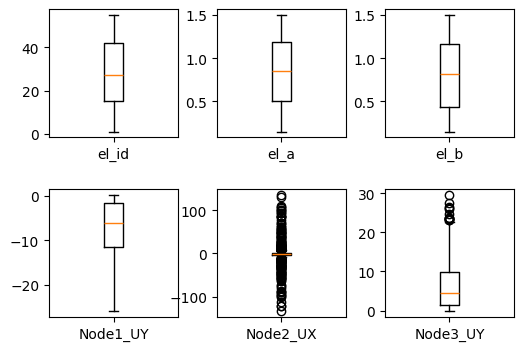

In [4]:
labels = df.columns.to_list()

fig, ax = plt.subplots(2, 3, figsize=(6, 4))
fig.subplots_adjust(hspace=0.4, wspace=0.3) 

for i in range(6):
    ax[i // 3, i % 3].boxplot(df.loc[:,[labels[i]]], tick_labels = [labels[i]])

plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY', 'el_id']].to_numpy()
y = df.drop(['Node1_UY', 'Node2_UX', 'Node3_UY', 'el_id'], axis=1).to_numpy()

scaler_X_2 = StandardScaler()
X_scaled = scaler_X_2.fit_transform(X)

scaler_y_2 = StandardScaler()
y_scaled = scaler_y_2.fit_transform(y)

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=42,
    shuffle=True
)

In [7]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

model = keras.Sequential([
    keras.Input(shape=(x_train.shape[1],)),
    keras.layers.Dense(4),
    
    keras.layers.Dense(16, activation='leaky_relu'
                       # , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    # keras.layers.Dropout(0.2),

    keras.layers.Dense(64, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(512, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1024, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1024, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(512, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(16, activation='leaky_relu'
                       # , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    # keras.layers.Dropout(0.2),

    keras.layers.Dense(2, activation='linear')
])

model.compile( optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss= 'mse',
                metrics = ['mae']
                )

callbacks = [
    EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=75, min_lr=1e-6, verbose=1)
]

In [8]:
history = model.fit(x_train, y_train, validation_split=0.2, batch_size=128, epochs=2000
                    ,callbacks=callbacks
                    , verbose=1)

Epoch 1/2000
6/6 [==============================] - 2s 72ms/step - loss: 2.2717 - mae: 1.1603 - val_loss: 0.9954 - val_mae: 0.8574 - lr: 0.0010
Epoch 2/2000
6/6 [==============================] - 0s 23ms/step - loss: 1.6230 - mae: 1.0085 - val_loss: 0.9888 - val_mae: 0.8532 - lr: 0.0010
Epoch 3/2000
6/6 [==============================] - 0s 24ms/step - loss: 1.4406 - mae: 0.9529 - val_loss: 0.9691 - val_mae: 0.8392 - lr: 0.0010
Epoch 4/2000
6/6 [==============================] - 0s 24ms/step - loss: 1.1965 - mae: 0.8657 - val_loss: 0.9782 - val_mae: 0.8372 - lr: 0.0010
Epoch 5/2000
6/6 [==============================] - 0s 26ms/step - loss: 0.9987 - mae: 0.7873 - val_loss: 1.0026 - val_mae: 0.8422 - lr: 0.0010
Epoch 6/2000
6/6 [==============================] - 0s 23ms/step - loss: 0.9035 - mae: 0.7697 - val_loss: 1.0340 - val_mae: 0.8490 - lr: 0.0010
Epoch 7/2000
6/6 [==============================] - 0s 24ms/step - loss: 0.8779 - mae: 0.7486 - val_loss: 1.0490 - val_mae: 0.8509 - lr:

In [9]:
from sklearn.metrics import r2_score

y_pred_scaled_test = model.predict(x_test)
y_pred_test = scaler_y_2.inverse_transform(y_pred_scaled_test)
y_true_test = scaler_y_2.inverse_transform(y_test)

y_pred_scaled_train = model.predict(x_train)
y_pred_train = scaler_y_2.inverse_transform(y_pred_scaled_train)
y_true_train = scaler_y_2.inverse_transform(y_train)

r2_train = r2_score(y_true_train, y_pred_train, multioutput='raw_values')
r2_test = r2_score(y_true_test, y_pred_test, multioutput='raw_values')
print(f"r2 на обущающей выборке: a={r2_train[0]:.2f}, b={r2_train[1]:.2f}")
#, b={r2_train[2]:.2f}")
print(f"r2 на тестовой выборке: a={r2_test[0]:.2f}, b={r2_test[1]:.2f}")
#, b={r2_test[2]:.2f}")


27/27 [==============================] - 0s 3ms/step
r2 на обущающей выборке: a=0.96, b=0.93
r2 на тестовой выборке: a=0.93, b=0.91


In [10]:
[ print('pred:', y_pred_test[i], '\ttrue:',  y_true_test[i], '\tdiff abs:', abs(y_pred_test[i]-y_true_test[i])) for i in range(10)]

pred: [0.53918004 1.3832886 ] 	true: [0.56 1.44] 	diff abs: [0.02081996 0.05671138]
pred: [1.2282498 0.9311003] 	true: [1.24 0.88] 	diff abs: [0.01175021 0.05110031]
pred: [0.82169247 0.3926002 ] 	true: [0.83 0.42] 	diff abs: [0.00830753 0.02739979]
pred: [0.64831656 0.7501371 ] 	true: [0.66 0.69] 	diff abs: [0.01168344 0.06013709]
pred: [0.6479001 1.1237825] 	true: [0.71 1.07] 	diff abs: [0.0620999  0.05378252]
pred: [0.45593867 0.9463475 ] 	true: [0.22 1.11] 	diff abs: [0.23593867 0.16365252]
pred: [1.3644185  0.45284218] 	true: [1.44 0.41] 	diff abs: [0.07558149 0.04284218]
pred: [0.5746217 0.4695477] 	true: [0.55 0.53] 	diff abs: [0.02462168 0.06045231]
pred: [0.98369455 0.36449304] 	true: [1.21 0.15] 	diff abs: [0.22630545 0.21449304]
pred: [0.35383362 0.3554537 ] 	true: [0.3  0.26] 	diff abs: [0.05383362 0.0954537 ]


[None, None, None, None, None, None, None, None, None, None]

In [11]:
#model.save('model_1_zone_part_2', save_format='tf')

INFO:tensorflow:Assets written to: model_1_zone_part_2\assets


In [80]:
import joblib
#joblib.dump(scaler_X_2, 'scaler_X_1_zone_part_2.pkl')
#joblib.dump(scaler_y_2, 'scaler_y_1_zone_part_2.pkl')

['scaler_y_1_zone_part_2.pkl']

In [60]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY']].to_numpy()
y = df[['el_id']].to_numpy()

scaler_X_1 = StandardScaler()
X_scaled = scaler_X_1.fit_transform(X)

scaler_y_1 = StandardScaler()
y_scaled = scaler_y_1.fit_transform(y)

In [61]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_scaled, 
    test_size=0.15, 
    random_state=42,
    shuffle=True,
    stratify = y_scaled
)

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

clf = RandomForestRegressor(n_estimators=500, max_depth=60, min_samples_split=2
                             , min_samples_leaf=2, random_state=42, verbose=0, bootstrap=False)
clf.fit(x_train, y_train)

print(f'r2 на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')

D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2 на обучающей выборке: 0.996, на тествой: 0.951


In [63]:
import joblib

#joblib.dump(clf, 'model_1_zone_part_1.pkl')
#joblib.dump(scaler_X_1, 'scaler_X_1_zone_part_1.pkl')
#joblib.dump(scaler_y_1, 'scaler_y_1_zone_part_1.pkl')

['scaler_y_1_zone_part_1.pkl']

In [ ]:
#проверка работы двух моделей: по трем перемещениям определить параметры id, a, b

In [4]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler
import joblib
import tensorflow as tf

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY']].to_numpy()
y = df.drop(['Node1_UY', 'Node2_UX', 'Node3_UY'], axis=1).to_numpy()

#определение id

scaler_X_1 = joblib.load('scaler_X_1_zone_part_1.pkl')
scaler_y_1 = joblib.load('scaler_y_1_zone_part_1.pkl')

X_scaled = scaler_X_1.transform(X)

reg = joblib.load('model_1_zone_part_1.pkl')

pred_id = scaler_y_1.inverse_transform(reg.predict(X_scaled).reshape(-1,1))
#pred_id = np.round(pred_id)

In [5]:
X_new = np.hstack((X, pred_id))

scaler_X_2 = joblib.load('scaler_X_1_zone_part_2.pkl')
scaler_y_2 = joblib.load('scaler_y_1_zone_part_2.pkl')

X_scaled_new = scaler_X_2.transform(X_new)

model = tf.keras.models.load_model('model_1_zone_part_2')

ab_pred_scal = model.predict(X_scaled_new)

32/32 [==============================] - 0s 3ms/step


In [6]:
ab_pred = scaler_y_2.inverse_transform(ab_pred_scal)
pred_data = np.hstack((pred_id, ab_pred))

In [7]:
from sklearn.metrics import r2_score

r2 = r2_score(pred_data, y, multioutput='raw_values')
print(f"r2 итоговой модели: id={r2[0]:.2f}, a={r2[1]:.2f}, b={r2[2]:.2f}")

r2 итоговой модели: id=0.99, a=0.84, b=0.75
